# Import libs

In [42]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from random import random

# Define data outlier

In [89]:
class SyntheticSineDataset:
    """
    Generates synthetic sine wave time series for anomaly detection.
    Normal sequence + 5 abnormal slices (global, contextual, shapelet, seasonal, trend outliers).
    """

    def __init__(self, length_normal=450, length_anomaly=50, noise_std=0.05, amplitude=1.0, freq=0.05, seed=0):
        self.length_normal = length_normal
        self.length_anomaly = length_anomaly
        self.noise_std = noise_std
        self.amp = amplitude
        self.freq = freq
        self.rng = np.random.RandomState(seed)

    def _normal(self, length):
        x = np.arange(length)
        y = self.amp * np.sin(2 * np.pi * self.freq * x)
        y += self.rng.normal(0, self.noise_std, size=length)
        return y

    def _contextual_outlier(self, y):
        """ Single value spike in context. """
        new_y = y.copy()
        pos = np.random.randint(self.length_normal // 2 - self.length_anomaly*2, self.length_normal // 2 + self.length_anomaly*2)
        new_y[pos] += self.amp * 3.0
        anomaly_y = np.zeros(self.length_normal)
        anomaly_y[pos] = 1
        return new_y, anomaly_y

    def _shapelet_outlier(self, y):
        new_y = y.copy()
        """ Inject a sudden 'shape' (e.g., square wave bump). """
        # y = self._normal(self.length_normal)
        start = np.random.randint(self.length_normal // 2 - self.length_anomaly*2, self.length_normal // 2 + self.length_anomaly*2)
        end = start + self.length_anomaly
        new_y[start:end] += self.amp * 2.5
        anomaly_y = np.zeros(self.length_normal)
        anomaly_y[start:end] = 1
        return new_y, anomaly_y

    def _trend_outlier(self, y):
        """Superimpose a linear trend in the middle of the sequence."""
        length = len(y)
        new_y = y.copy()
        start_idx = np.random.randint(self.length_normal // 2 - self.length_anomaly*2, self.length_normal // 2 + self.length_anomaly*2)
        end_idx = start_idx + self.length_anomaly
        
        # Apply trend only to the middle segment
        new_y[start_idx:end_idx] += np.linspace(start=0, stop=self.amp * 3, num=self.length_anomaly)
        anomaly_y = np.zeros(self.length_normal)
        anomaly_y[start_idx:end_idx] = 1
        return new_y, anomaly_y

    def make(self):
        """
        Returns:
            - normal_train: 1D np.array, normal sine (for training)
            - abnormal_dict: dict of name -> (series, labels)
              where series is 1D np.array, labels is 0/1 per point (anomaly at that point)
        """
        # Normal for training
        normal_train = self._normal(self.length_normal)

        # For each anomaly type, produce a test sequence with labels
        slices = {
            "contextual": self._contextual_outlier(normal_train),
            "shapelet": self._shapelet_outlier(normal_train),
            "trend": self._trend_outlier(normal_train)
        }
        return normal_train, slices


contextual: anomaly count = 1
shapelet: anomaly count = 50
trend: anomaly count = 50


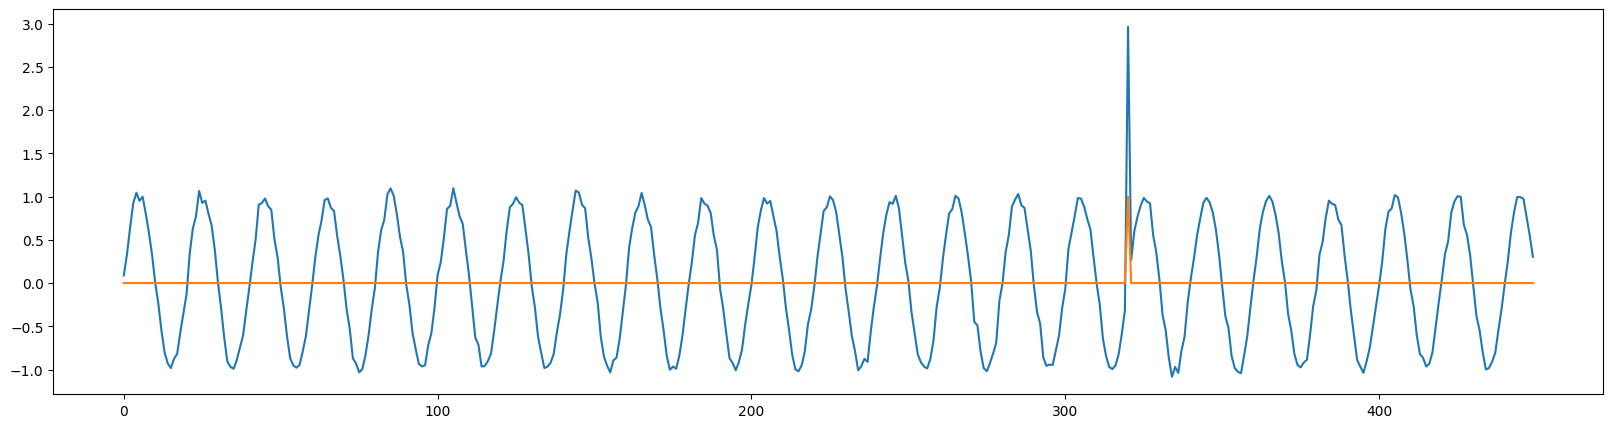

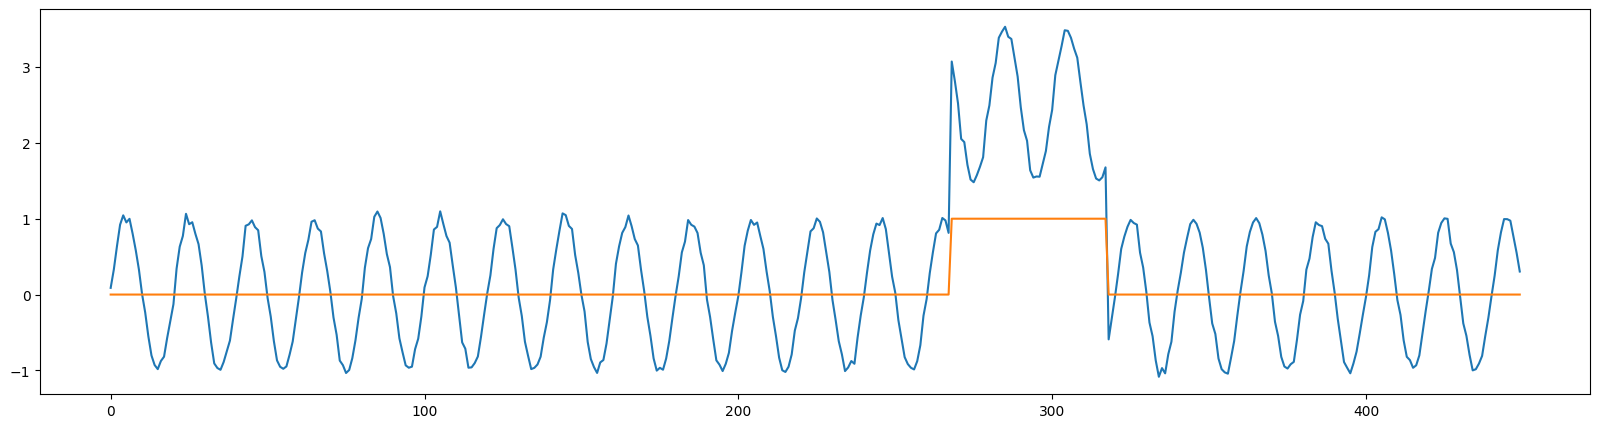

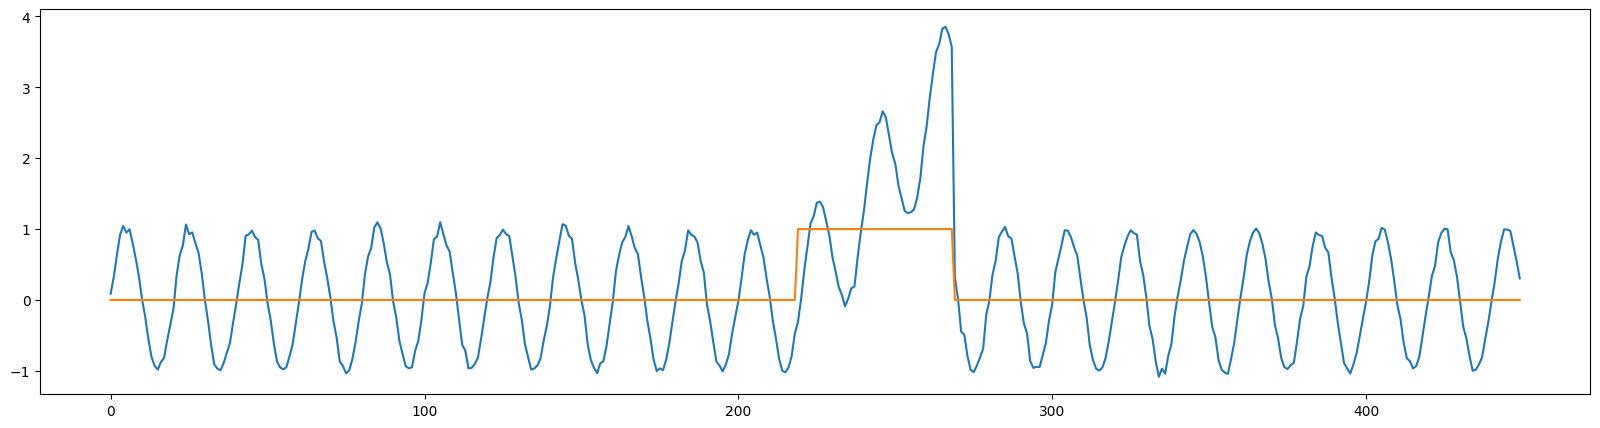

In [92]:
# --- Example usage ---

if __name__ == "__main__":
    gen = SyntheticSineDataset()
    normal_train, abnormal_dict = gen.make()

    # Plot all anomaly types
    for name in abnormal_dict.keys():
        tmp_data = abnormal_dict.get(name)
        plt.figure(figsize=(20,5))
        print(f"{name}:", "anomaly count =", int(tmp_data[1].sum()))
        plt.plot(tmp_data[0])
        plt.plot(tmp_data[1])